##Task 3: Heart Disease Prediction

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)

Loading Heart Dataset

In [9]:
df = pd.read_csv("HeartDiseaseTrain-Test.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


Data Inspection

In [10]:
print("DATASET SHAPE: ",df.shape)

DATASET SHAPE:  (1025, 14)


In [11]:
print("\nCOLUMNS: ",df.columns)


COLUMNS:  Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='object')


In [12]:
print("\nDATASET INFORMATION: ",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [13]:
print("STATISTICAL SUMMARY: ",df.describe())

STATISTICAL SUMMARY:                 age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%      56.000000              130.000000    240.00000      152.000000   
75%      61.000000              140.000000    275.00000      166.000000   
max      77.000000              200.000000    564.00000      202.000000   

           oldpeak       target  
count  1025.000000  1025.000000  
mean      1.071512     0.513171  
std       1.175053     0.500070  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.800000     1.000000  
75%       1.800000     1.000000  
max       6.200000     1.00000

#Data Cleaning

Removing duplicates

In [16]:
df = df.drop_duplicates()

Checking missing values

In [14]:
missing_val=df.isnull().sum()
print("MISSING VALUES: ",missing_val)

MISSING VALUES:  age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [17]:
df = df.dropna()

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

#Performing Exploratory Data Analysis (EDA)

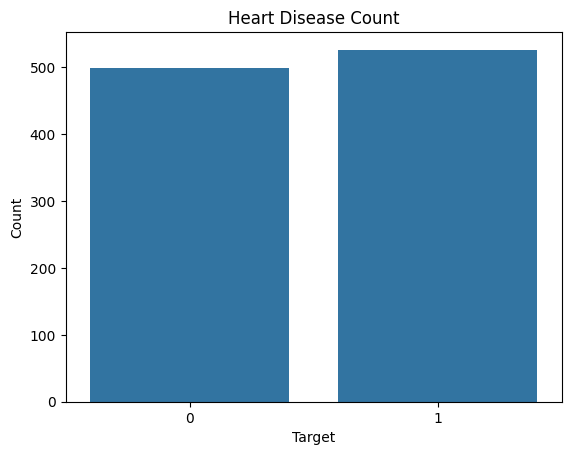

In [15]:
sb.countplot(x="target",data=df)
plt.title("Heart Disease Count")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

#Correlation Heatmap

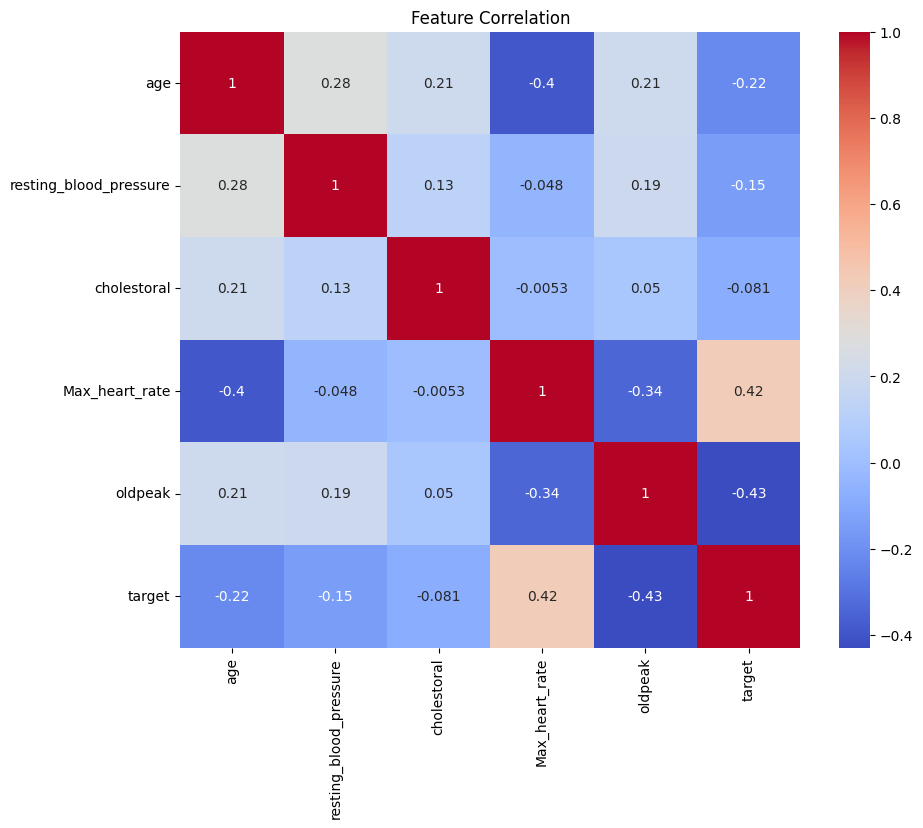

In [22]:
plt.figure(figsize=(10,8))
numeric_df = df_encoded.select_dtypes(include=['number'])
sb.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()




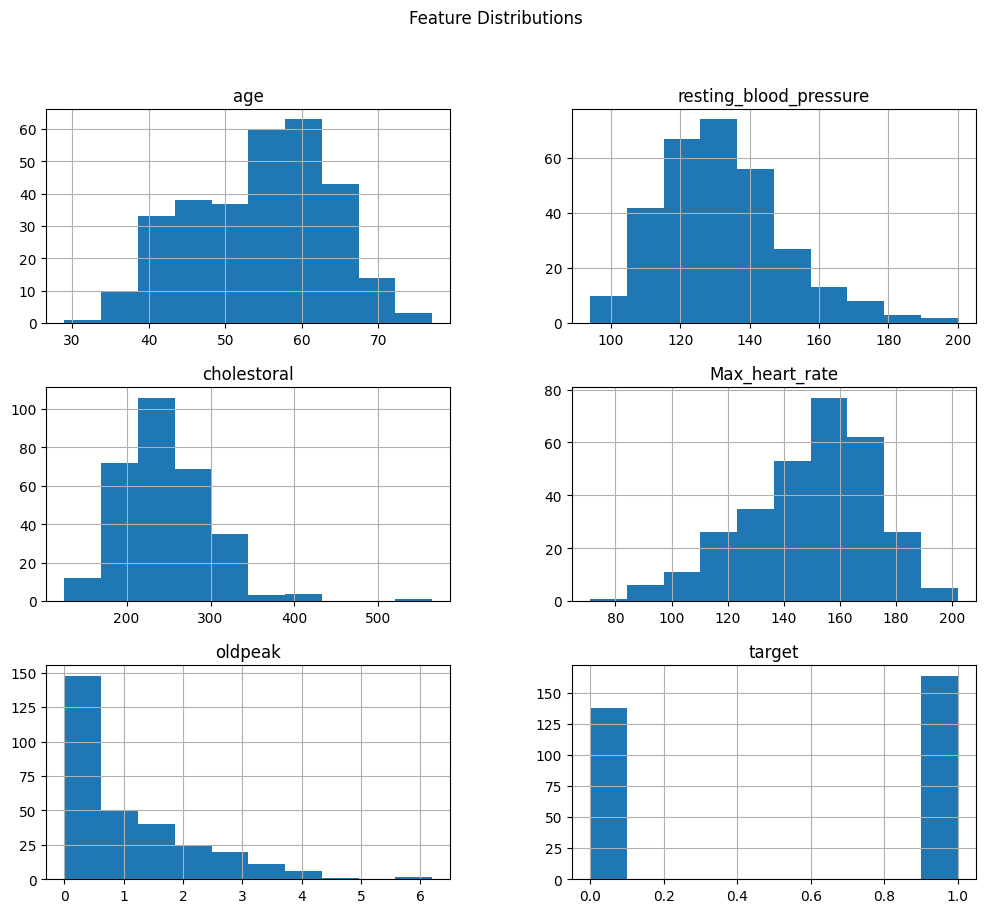

In [23]:
df_encoded.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

Split features and target

In [24]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2,random_state=42)

Train Model

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions


In [33]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Evaluation Metrics

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.819672131147541


In [35]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        32
           1       0.78      0.86      0.82        29

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Confusion Matrix

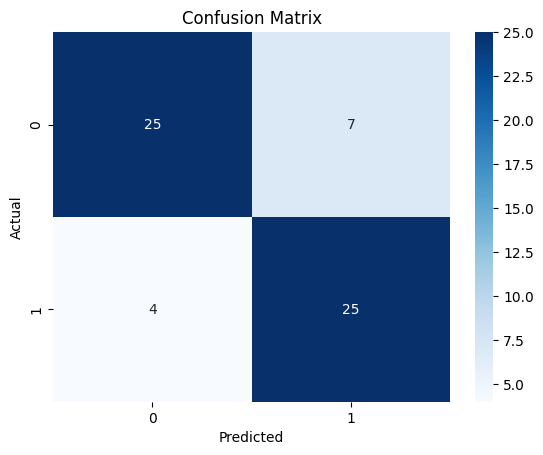

In [36]:
cm = confusion_matrix(y_test, y_pred)
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve

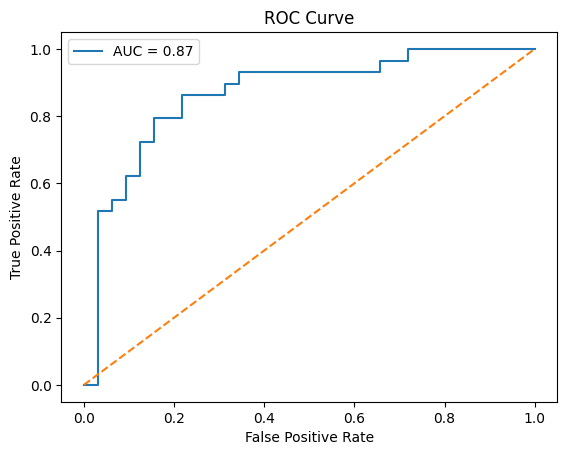

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Feature Importance:

                                     Feature  Importance
11            rest_ecg_ST-T wave abnormality    0.339662
3                             Max_heart_rate    0.319445
18        vessels_colored_by_flourosopy_Zero    0.283404
0                                        age    0.072423
7           chest_pain_type_Non-anginal pain    0.069636
9   fasting_blood_sugar_Lower than 120 mg/ml   -0.097193
12               exercise_induced_angina_Yes   -0.107251
2                                cholestoral   -0.111542
19                            thalassemia_No   -0.198650
14                           slope_Upsloping   -0.203538
10                           rest_ecg_Normal   -0.228590
20                        thalassemia_Normal   -0.290317
6            chest_pain_type_Atypical angina   -0.303737
16       vessels_colored_by_flourosopy_Three   -0.376311
13                                slope_Flat   -0.402054
17         vessels_colored_by_flourosopy_Two   -0.448021
1        

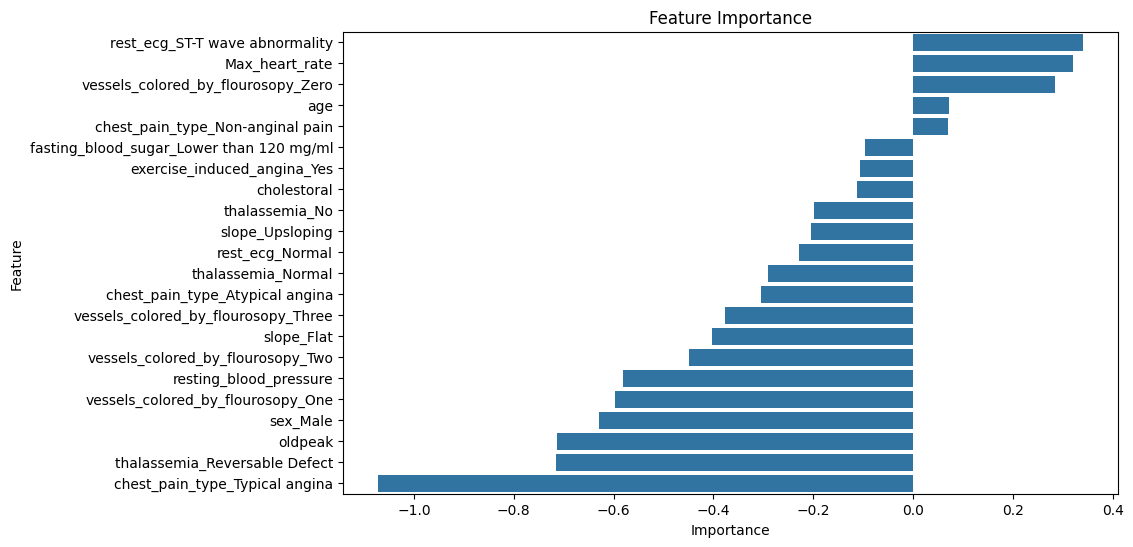

In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n")
print(importance)

plt.figure(figsize=(10,6))
sb.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()